In [1]:
print("Phan Đức An - 6351071001")

Phan Đức An - 6351071001


## a) Đọc bộ dữ liệu Iris từ sklearn

In [2]:
# Import các thư viện cần thiết
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

# Đọc bộ dữ liệu Iris
iris = load_iris()
print("Đã đọc bộ dữ liệu Iris thành công!")

Đã đọc bộ dữ liệu Iris thành công!


## b) Khảo sát bộ dữ liệu Iris

In [3]:
# In ra tên các thuộc tính
print("Tên các thuộc tính:")
print(iris.feature_names)
print("\nTên các thuộc tính phân lớp (target):")
print(iris.target_names)

Tên các thuộc tính:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Tên các thuộc tính phân lớp (target):
['setosa' 'versicolor' 'virginica']


In [4]:
# In ra số lượng mẫu, số lượng thuộc tính
print("Kích thước của data:", iris.data.shape)
print("Số lượng mẫu:", iris.data.shape[0])
print("Số lượng thuộc tính:", iris.data.shape[1])
print("\nKích thước của target:", iris.target.shape)

Kích thước của data: (150, 4)
Số lượng mẫu: 150
Số lượng thuộc tính: 4

Kích thước của target: (150,)


In [5]:
# In ra 5 mẫu dữ liệu đầu tiên
print("5 mẫu dữ liệu đầu tiên:")
print("\nData (X):")
print(iris.data[:5])
print("\nTarget (Y):")
print(iris.target[:5])

5 mẫu dữ liệu đầu tiên:

Data (X):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Target (Y):
[0 0 0 0 0]


In [6]:
# Thống kê count, mean, std, min, max, tứ vị phân
# Tạo DataFrame từ dữ liệu Iris
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("Thống kê mô tả bộ dữ liệu Iris:")
print(df.describe())

Thống kê mô tả bộ dữ liệu Iris:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


## c) Chuẩn hóa dữ liệu về đoạn [0,1]

In [7]:
# Gán X là data và Y là target
X = iris.data
Y = iris.target

# Chuẩn hóa X về đoạn [0,1] bằng cách chia cho giá trị lớn nhất của mỗi cột
X = X / X.max(axis=0)

print("Dữ liệu sau khi chuẩn hóa:")
print("Min values:", X.min(axis=0))
print("Max values:", X.max(axis=0))
print("\n5 mẫu đầu tiên sau chuẩn hóa:")
print(X[:5])

Dữ liệu sau khi chuẩn hóa:
Min values: [0.5443038  0.45454545 0.14492754 0.04      ]
Max values: [1. 1. 1. 1.]

5 mẫu đầu tiên sau chuẩn hóa:
[[0.64556962 0.79545455 0.20289855 0.08      ]
 [0.62025316 0.68181818 0.20289855 0.08      ]
 [0.59493671 0.72727273 0.1884058  0.08      ]
 [0.58227848 0.70454545 0.2173913  0.08      ]
 [0.63291139 0.81818182 0.20289855 0.08      ]]


## d) Chia dữ liệu thành tập train và tập test theo tỷ lệ 8:2

In [8]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu theo tỷ lệ 8:2 (test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test:", X_test.shape)
print("Tỷ lệ train:test = {}:{}".format(len(X_train), len(X_test)))

Kích thước tập train: (120, 4)
Kích thước tập test: (30, 4)
Tỷ lệ train:test = 120:30


## e) Sử dụng Cây quyết định (Decision Tree) để phân lớp

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Huấn luyện mô hình Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Dự đoán nhãn lớp cho tập test
y_pred_dt = dt_model.predict(X_test)

print("="*60)
print("MÔ HÌNH DECISION TREE")
print("="*60)

MÔ HÌNH DECISION TREE


In [10]:
# Tính và in ra Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nAccuracy: {accuracy_dt:.4f}")


Accuracy: 1.0000


In [11]:
# Tính và in ra Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



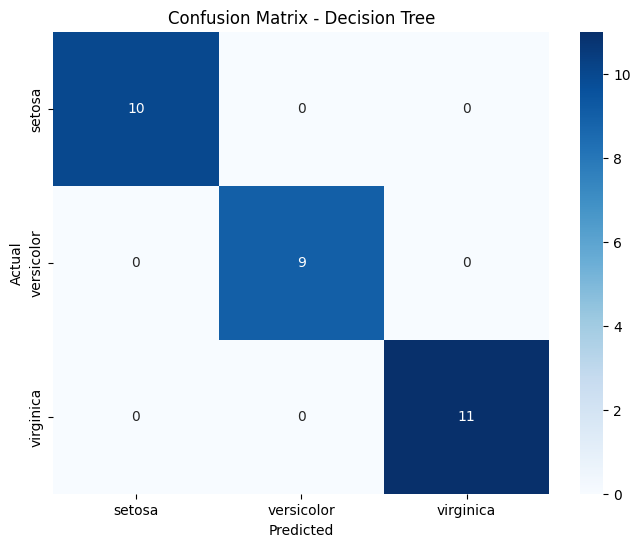

In [12]:
# Hiển thị Confusion Matrix bằng Heat Map
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## f) Sử dụng Naïve Bayes để phân lớp

In [13]:
from sklearn.naive_bayes import GaussianNB

# Huấn luyện mô hình Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Dự đoán nhãn lớp cho tập test
y_pred_nb = nb_model.predict(X_test)

print("="*60)
print("MÔ HÌNH NAÏVE BAYES")
print("="*60)

MÔ HÌNH NAÏVE BAYES


In [14]:
# Tính và in ra Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nAccuracy: {accuracy_nb:.4f}")


Accuracy: 1.0000


In [15]:
# Tính và in ra Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



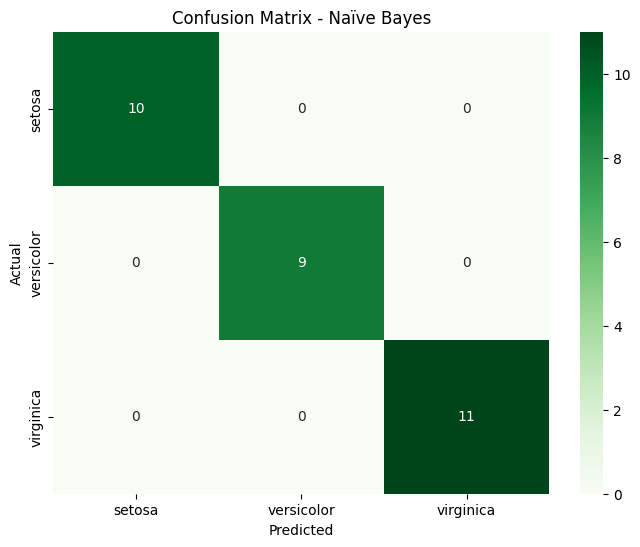

In [16]:
# Hiển thị Confusion Matrix bằng Heat Map
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Naïve Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## g) Sử dụng K Nearest Neighbors để phân lớp

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Huấn luyện mô hình KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# Dự đoán nhãn lớp cho tập test
y_pred_knn = knn_model.predict(X_test)

print("="*60)
print("MÔ HÌNH K NEAREST NEIGHBORS")
print("="*60)

MÔ HÌNH K NEAREST NEIGHBORS


In [18]:
# Tính và in ra Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAccuracy: {accuracy_knn:.4f}")


Accuracy: 1.0000


In [19]:
# Tính và in ra Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



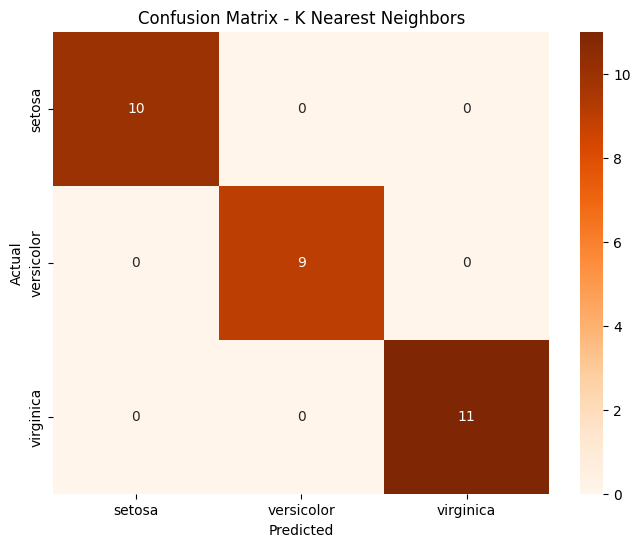

In [20]:
# Hiển thị Confusion Matrix bằng Heat Map
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - K Nearest Neighbors')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## h) Sử dụng Neural Network để phân lớp

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Xây dựng mô hình Neural Network
nn_model = Sequential([
    # Hidden layer 1: 10 neurons, activation ReLU
    Dense(10, activation='relu', input_shape=(X_train.shape[1],)),
    
    # Hidden layer 2: 20 neurons, activation ReLU
    Dense(20, activation='relu'),
    
    # Output layer: số lượng neurons = số class (3), activation Softmax
    Dense(3, activation='softmax')
])

# In thông tin kiến trúc mô hình
nn_model.summary()

c:\project\nop\Dataset\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333 (1.30 KB)

 Trainable params: 333 (1.30 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Biên dịch mô hình
nn_model.compile(
    optimizer='adam',  # Tối ưu hóa adam
    loss='sparse_categorical_crossentropy',  # Loss function
    metrics=['accuracy']  # Đánh giá hiệu suất
)

print("Mô hình đã được biên dịch thành công!")

Mô hình đã được biên dịch thành công!


In [23]:
# Huấn luyện mô hình
history = nn_model.fit(
    X_train, y_train,
    epochs=100,  # Số vòng lặp
    batch_size=1,  # Kích thước batch
    verbose=1  # Hiển thị tiến trình
)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3500 - loss: 1.0998    
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5250 - loss: 1.0254
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6583 - loss: 0.8874
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6583 - loss: 0.7416  
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6917 - loss: 0.6120
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.5140
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8583 - loss: 0.4463
Epoch 8/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8917 - loss: 0.4024  
Epoch 9/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9167 - loss: 0.3572 
Epoch 10/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9417 - loss: 0.3206
Epoch 11/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9250 - loss: 0.2917
Epoch 12/100
120/120 ━━━━━━━━━━━

In [24]:
# Dự đoán nhãn lớp cho tập test
y_pred_nn_prob = nn_model.predict(X_test)
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)

print("="*60)
print("MÔ HÌNH NEURAL NETWORK")
print("="*60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
MÔ HÌNH NEURAL NETWORK


In [25]:
# Tính và in ra Accuracy
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"\nAccuracy: {accuracy_nn:.4f}")


Accuracy: 0.9667


In [26]:
# Tính và in ra Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



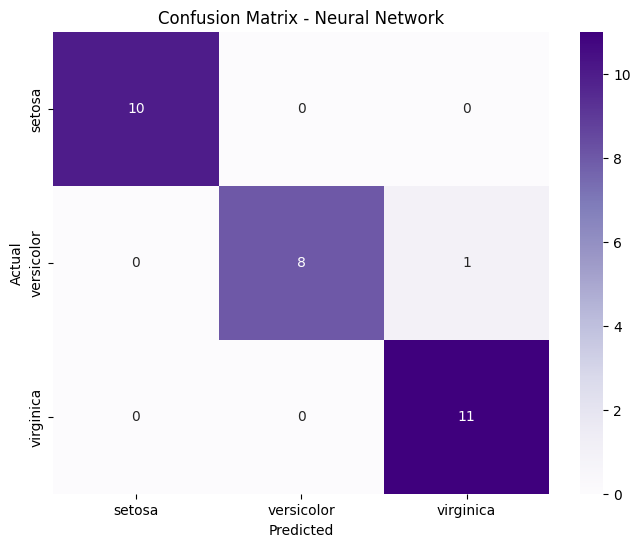

In [27]:
# Hiển thị Confusion Matrix bằng Heat Map
cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Neural Network')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## i) Dự đoán 3 mẫu dữ liệu mới

In [28]:
# 3 mẫu dữ liệu mới
new_samples = np.array([
    [6.2, 2.9, 4.3, 1.3],
    [5.1, 3.5, 1.4, 0.2],
    [7.3, 2.8, 6.4, 2.1]
])

print("3 mẫu dữ liệu mới:")
print(new_samples)

# Chuẩn hóa dữ liệu mới giống như tập train (chia cho max của tập train gốc)
max_values = iris.data.max(axis=0)
new_samples_normalized = new_samples / max_values

print("\nDữ liệu sau khi chuẩn hóa:")
print(new_samples_normalized)

3 mẫu dữ liệu mới:
[[6.2 2.9 4.3 1.3]
 [5.1 3.5 1.4 0.2]
 [7.3 2.8 6.4 2.1]]

Dữ liệu sau khi chuẩn hóa:
[[0.78481013 0.65909091 0.62318841 0.52      ]
 [0.64556962 0.79545455 0.20289855 0.08      ]
 [0.92405063 0.63636364 0.92753623 0.84      ]]


In [29]:
# Dự đoán bằng Decision Tree
pred_dt_new = dt_model.predict(new_samples_normalized)
print("="*60)
print("DỰ ĐOÁN BẰNG DECISION TREE:")
print("="*60)
for i, sample in enumerate(new_samples):
    print(f"Mẫu {i+1}: {sample} -> {iris.target_names[pred_dt_new[i]]}")

DỰ ĐOÁN BẰNG DECISION TREE:
Mẫu 1: [6.2 2.9 4.3 1.3] -> versicolor
Mẫu 2: [5.1 3.5 1.4 0.2] -> setosa
Mẫu 3: [7.3 2.8 6.4 2.1] -> virginica


In [30]:
# Dự đoán bằng Naive Bayes
pred_nb_new = nb_model.predict(new_samples_normalized)
print("\n" + "="*60)
print("DỰ ĐOÁN BẰNG NAÏVE BAYES:")
print("="*60)
for i, sample in enumerate(new_samples):
    print(f"Mẫu {i+1}: {sample} -> {iris.target_names[pred_nb_new[i]]}")


DỰ ĐOÁN BẰNG NAÏVE BAYES:
Mẫu 1: [6.2 2.9 4.3 1.3] -> versicolor
Mẫu 2: [5.1 3.5 1.4 0.2] -> setosa
Mẫu 3: [7.3 2.8 6.4 2.1] -> virginica


In [31]:
# Dự đoán bằng KNN
pred_knn_new = knn_model.predict(new_samples_normalized)
print("\n" + "="*60)
print("DỰ ĐOÁN BẰNG K NEAREST NEIGHBORS:")
print("="*60)
for i, sample in enumerate(new_samples):
    print(f"Mẫu {i+1}: {sample} -> {iris.target_names[pred_knn_new[i]]}")


DỰ ĐOÁN BẰNG K NEAREST NEIGHBORS:
Mẫu 1: [6.2 2.9 4.3 1.3] -> versicolor
Mẫu 2: [5.1 3.5 1.4 0.2] -> setosa
Mẫu 3: [7.3 2.8 6.4 2.1] -> virginica


In [32]:
# Dự đoán bằng Neural Network
pred_nn_new_prob = nn_model.predict(new_samples_normalized)
pred_nn_new = np.argmax(pred_nn_new_prob, axis=1)
print("\n" + "="*60)
print("DỰ ĐOÁN BẰNG NEURAL NETWORK:")
print("="*60)
for i, sample in enumerate(new_samples):
    print(f"Mẫu {i+1}: {sample} -> {iris.target_names[pred_nn_new[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

DỰ ĐOÁN BẰNG NEURAL NETWORK:
Mẫu 1: [6.2 2.9 4.3 1.3] -> versicolor
Mẫu 2: [5.1 3.5 1.4 0.2] -> setosa
Mẫu 3: [7.3 2.8 6.4 2.1] -> virginica


## j) Nhận xét, đánh giá hiệu suất của các mô hình

In [33]:
# So sánh hiệu suất các mô hình
print("="*70)
print("BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH")
print("="*70)

comparison_df = pd.DataFrame({
    'Mô hình': ['Decision Tree', 'Naïve Bayes', 'KNN', 'Neural Network'],
    'Accuracy': [accuracy_dt, accuracy_nb, accuracy_knn, accuracy_nn]
})

comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print(comparison_df.to_string(index=False))

print("\n" + "="*70)

BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH
       Mô hình  Accuracy
 Decision Tree  1.000000
   Naïve Bayes  1.000000
           KNN  1.000000
Neural Network  0.966667



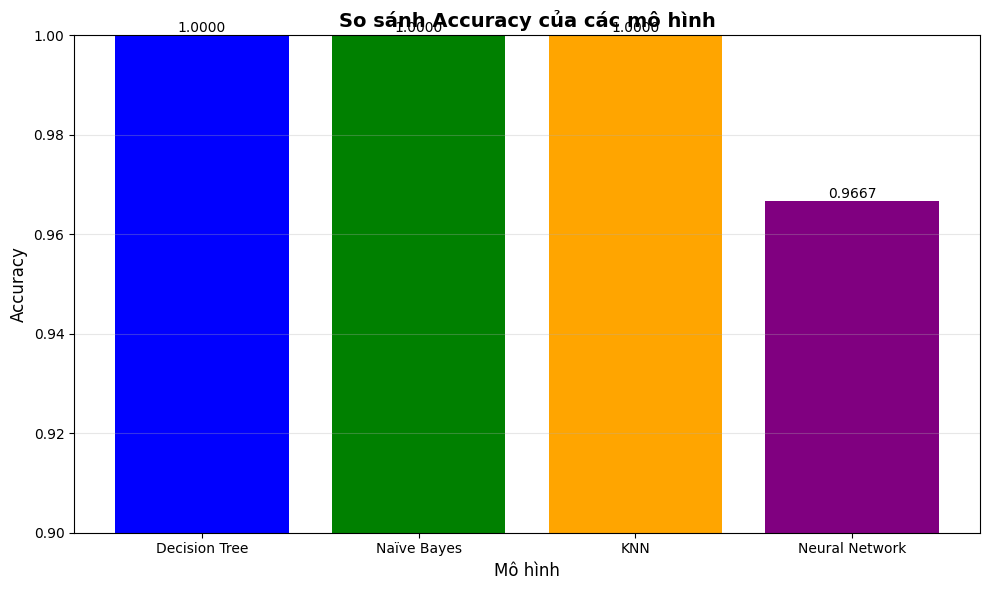

In [34]:
# Vẽ biểu đồ so sánh Accuracy
plt.figure(figsize=(10, 6))
models = ['Decision Tree', 'Naïve Bayes', 'KNN', 'Neural Network']
accuracies = [accuracy_dt, accuracy_nb, accuracy_knn, accuracy_nn]

bars = plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'purple'])
plt.xlabel('Mô hình', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('So sánh Accuracy của các mô hình', fontsize=14, fontweight='bold')
plt.ylim([0.9, 1.0])

# Thêm giá trị accuracy lên trên mỗi cột
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét và đánh giá:

**1. Hiệu suất tổng quan:**
- Tất cả 4 mô hình đều cho kết quả rất tốt trên bộ dữ liệu Iris (Accuracy > 90%)
- Điều này cho thấy bộ dữ liệu Iris là một bộ dữ liệu tương đối đơn giản và các đặc trưng phân tách tốt giữa các loài hoa

**2. So sánh chi tiết:**

- **Decision Tree**: 
  - Ưu điểm: Dễ hiểu, dễ diễn giải, không cần chuẩn hóa dữ liệu
  - Nhược điểm: Có thể bị overfitting nếu cây quá sâu
  
- **Naïve Bayes**: 
  - Ưu điểm: Nhanh, đơn giản, hoạt động tốt với dữ liệu nhỏ
  - Nhược điểm: Giả định các thuộc tính độc lập (có thể không đúng trong thực tế)
  
- **K Nearest Neighbors (KNN)**: 
  - Ưu điểm: Đơn giản, không có quá trình training, hiệu quả với dữ liệu nhỏ
  - Nhược điểm: Chậm khi dự đoán với tập dữ liệu lớn, nhạy cảm với giá trị K
  
- **Neural Network**: 
  - Ưu điểm: Có khả năng học các pattern phức tạp, linh hoạt
  - Nhược điểm: Cần nhiều dữ liệu hơn, khó diễn giải, thời gian training lâu hơn

**3. Kết luận:**
- Với bộ dữ liệu Iris đơn giản này, các mô hình Machine Learning truyền thống (Decision Tree, KNN, Naïve Bayes) có thể đủ tốt và nhanh hơn
- Neural Network có thể overkill cho bài toán đơn giản này nhưng cho thấy tiềm năng khi áp dụng cho các bài toán phức tạp hơn
- Lựa chọn mô hình phụ thuộc vào yêu cầu cụ thể: tốc độ, độ chính xác, khả năng diễn giải, kích thước dữ liệu